In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [13]:
df = pd.read_csv('encuesta_salud.csv')

df.head()

,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa,grupo_sanguineo,region,diagnostico
0,1,56.00,86.80,1.80,124.80,231.00,77.50,B-,Araucania,Sano
1,2,69.00,72.70,1.46,104.40,148.90,102.50,A+,Biobio,Hipertension
2,3,46.00,84.20,1.50,164.50,220.30,78.30,AB+,Valparaiso,Hipertension
3,4,32.00,86.90,1.63,95.20,218.40,60.50,AB-,Araucania,Prediabetes
4,5,NaN,58.60,1.78,130.50,152.60,400.00,B-,Biobio,Sano


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                500 non-null    int64  
 1   edad              455 non-null    float64
 2   peso_kg           440 non-null    float64
 3   talla_m           500 non-null    float64
 4   presion_arterial  500 non-null    float64
 5   colesterol        460 non-null    float64
 6   glucosa           500 non-null    float64
 7   grupo_sanguineo   475 non-null    str    
 8   region            500 non-null    str    
 9   diagnostico       470 non-null    str    
dtypes: float64(6), int64(1), str(3)
memory usage: 39.2 KB


In [15]:
df.describe()

,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,500.00,455.00,440.00,500.00,500.00,460.00,500.00
mean,250.50,50.18,72.44,6.76,123.15,193.66,101.81
std,144.48,18.21,14.32,28.92,29.66,34.47,47.26
min,1.00,18.00,34.80,1.33,62.20,102.60,18.60
25%,125.75,35.00,63.27,1.61,106.35,170.15,80.38
50%,250.50,50.00,72.35,1.69,120.75,193.95,97.45
75%,375.25,66.00,82.93,1.75,133.68,217.05,112.80
max,500.00,79.00,111.00,186.00,290.00,290.60,420.00


In [16]:
df.isnull().sum()

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

In [21]:
Q1 = df['talla_m'].quantile(0.25)
Q3 = df['talla_m'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Limite inferior: {lim_inf}")
print(f"Limite superior: {lim_sup}")

Limite inferior: 1.4000000000000004
Limite superior: 1.96


In [24]:
# Rellenar numéricos con media
df['edad'].fillna(df['edad'].mean(), inplace=True)
df['peso_kg'].fillna(df['peso_kg'].mean(), inplace=True)

# Rellenar categóricos con moda
df['region'].fillna(df['region'].mode()[0], inplace=True)

# Corregir talla (cm → m)
df['talla_m'] = df['talla_m'].apply(lambda x: x/100 if x > 3 else x)

# Verificación
df.isnull().sum()

/tmp/ipykernel_14080/3070971599.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['edad'].fillna(df['edad'].mean(), inplace=True)
/tmp/ipykernel_14080/3070971599.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never work

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

In [25]:
Q1 = df['presion_arterial'].quantile(0.25)
Q3 = df['presion_arterial'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['presion_arterial'] < lim_inf) | (df['presion_arterial'] > lim_sup)]

print(len(outliers))

15


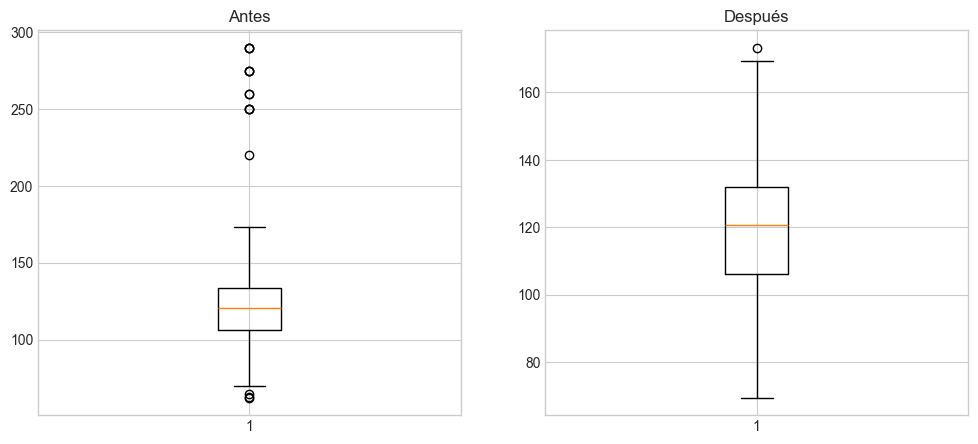

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['presion_arterial'])
axes[0].set_title('Antes')

df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

axes[1].boxplot(df_limpio['presion_arterial'])
axes[1].set_title('Después')

plt.show()

In [27]:
z_scores = np.abs(stats.zscore(df['glucosa']))
df = df[z_scores <= 3]

In [28]:
cols = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']

scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[cols] = scaler.fit_transform(df[cols])

df_minmax[cols].describe()

,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,446.00,431.00,490.00,490.00,451.00,490.00
mean,0.53,0.49,0.54,0.27,0.49,0.57
std,0.30,0.19,0.15,0.13,0.18,0.16
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.28,0.37,0.43,0.20,0.36,0.46
50%,0.52,0.49,0.54,0.26,0.49,0.58
75%,0.79,0.63,0.64,0.32,0.61,0.69
max,1.00,1.00,1.00,1.00,1.00,1.00


In [29]:
df_final = df_minmax.copy()

df_final = pd.get_dummies(df_final, columns=['region'], drop_first=True)
df_final = pd.get_dummies(df_final, columns=['grupo_sanguineo'], drop_first=True)

In [30]:
le = LabelEncoder()
df_final['diagnostico_cod'] = le.fit_transform(df_final['diagnostico'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Diabetes': np.int64(0), 'Hipertension': np.int64(1), 'Obesidad': np.int64(2), 'Prediabetes': np.int64(3), 'Sano': np.int64(4), nan: np.int64(5)}


In [31]:
print(df.shape)
print(df_final.shape)

(490, 10)
(490, 20)
